In [3]:
import pandas as pd
import numpy as np
import sklearn 
import matplotlib.pyplot as plt
import seaborn as sns 

In [4]:
path=r"E:\Downloads\preprocessd_data_cleaned - preprocessd_data_cleaned.csv"
df=pd.read_csv(path)
df

,gender,age,no_of_days_subscribed,multi_screen,mail_subscribed,weekly_mins_watched,minimum_daily_mins,weekly_max_night_mins,videos_watched,customer_support_calls,churn
0,0,-0.264643,-0.946659,0,0,-1.508785,0.722258,-0.944404,-1.403000,-0.415473,0
1,0,0.029654,1.235009,0,0,0.304821,-0.901748,-0.688523,-0.599124,0.347522,0
2,0,2.580235,0.658246,0,0,-2.266627,0.613991,-0.483818,-1.403000,2.636507,1
3,0,-1.441834,0.783629,0,1,0.638123,-0.252146,0.079121,-0.197185,1.110517,0
4,0,0.127754,2.288228,0,0,-0.333851,0.253101,-0.893228,1.008630,-0.415473,0
...,...,...,...,...,...,...,...,...,...,...,...
3401,1,-0.805656,0.479710,0,0,0.887802,0.552184,0.865765,-0.495634,-0.415473,1
3402,0,0.477826,0.674425,0,0,2.038061,-0.931071,0.567257,2.100185,0.235227,1
3403,0,-0.550521,0.426099,0,1,-0.410669,0.344847,-0.729485,-0.403904,1.873512,1
3404,0,0.004651,-0.444637,0,0,1.359751,-0.847121,-0.715010,-0.197185,-1.178468,1


In [5]:
X=df.drop('churn',axis=1)
y=df['churn']

In [6]:
X.shape

(3406, 10)

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1234)

In [13]:
X_train.shape,y_train.shape

((2724, 10), (2724,))

In [15]:
X_test.shape,y_test.shape

((682, 10), (682,))

In [17]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [19]:
svm=SVC()
knn=KNeighborsClassifier()
nv=BernoulliNB()
rf=RandomForestClassifier()
lr=LogisticRegression()
dt=DecisionTreeClassifier()

In [25]:
# SVM prediction
y_pred_svm = svm.predict(X_test)

# KNN prediction
y_pred_knn = knn.predict(X_test)

# Naive Bayes prediction
y_pred_nv = nv.predict(X_test)

# Random Forest prediction
y_pred_rf = rf.predict(X_test)

# Logistic Regression prediction
y_pred_lr = lr.predict(X_test)

# Decision Tree prediction
y_pred_dt = dt.predict(X_test)

In [43]:
import numpy as np

models = {
    "SVM": y_pred_svm,
    "KNN": y_pred_knn,
    "Naive Bayes": y_pred_nv,
    "Random Forest": y_pred_rf,
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt
}

for name, pred in models.items():

    tp = np.sum((y_test==1) & (pred==1))
    tn = np.sum((y_test==0) & (pred==0))
    fp = np.sum((y_test==0) & (pred==1))
    fn = np.sum((y_test==1) & (pred==0))

    print(f"\n{name}")
    print("TP:",tp)
    print("TN:",tn)
    print("FP:",fp)
    print("FN:",fn)


SVM
TP: 293
TN: 307
FP: 37
FN: 45

KNN
TP: 332
TN: 268
FP: 76
FN: 6

Naive Bayes
TP: 237
TN: 217
FP: 127
FN: 101

Random Forest
TP: 313
TN: 325
FP: 19
FN: 25

Logistic Regression
TP: 249
TN: 255
FP: 89
FN: 89

Decision Tree
TP: 301
TN: 291
FP: 53
FN: 37


In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

models = {
    "SVM": y_pred_svm,
    "KNN": y_pred_knn,
    "Naive Bayes": y_pred_nv,
    "Random Forest": y_pred_rf,
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt
}

for name, pred in models.items():

    ps = precision_score(y_test, pred)
    rs = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    acc = accuracy_score(y_test, pred)

    print(f"\n{name} Metrics")
    print("Accuracy:", acc)
    print("Precision:", ps)
    print("Recall:", rs)
    print("F1 Score:", f1)




SVM Metrics
Accuracy: 0.8797653958944281
Precision: 0.8878787878787879
Recall: 0.8668639053254438
F1 Score: 0.8772455089820359

KNN Metrics
Accuracy: 0.8797653958944281
Precision: 0.8137254901960784
Recall: 0.9822485207100592
F1 Score: 0.8900804289544236

Naive Bayes Metrics
Accuracy: 0.6656891495601173
Precision: 0.6510989010989011
Recall: 0.7011834319526628
F1 Score: 0.6752136752136753

Random Forest Metrics
Accuracy: 0.9354838709677419
Precision: 0.9427710843373494
Recall: 0.9260355029585798
F1 Score: 0.9343283582089552

Logistic Regression Metrics
Accuracy: 0.7390029325513197
Precision: 0.7366863905325444
Recall: 0.7366863905325444
F1 Score: 0.7366863905325444

Decision Tree Metrics
Accuracy: 0.8680351906158358
Precision: 0.8502824858757062
Recall: 0.8905325443786982
F1 Score: 0.869942196531792


In [39]:
print(f"precision_score : {ps}, Recall Score : {rs}, F1 Score : {f1}, Accuracy : {accuracy},confusion_matrix : {confusion_matrix}")

precision_score : 0.8502824858757062, Recall Score : 0.8905325443786982, F1 Score : 0.869942196531792, Accuracy : 0.8797653958944281,confusion_matrix : <function confusion_matrix at 0x000002E4B1216AC0>


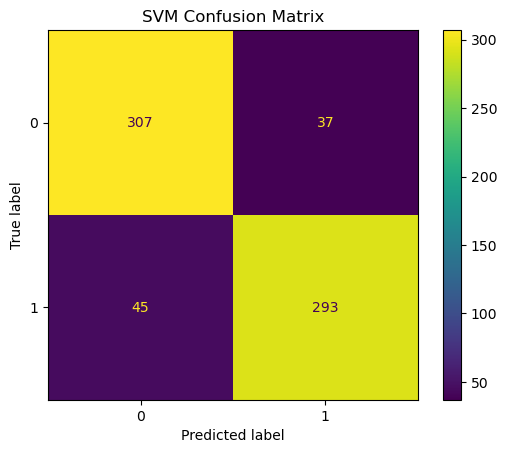

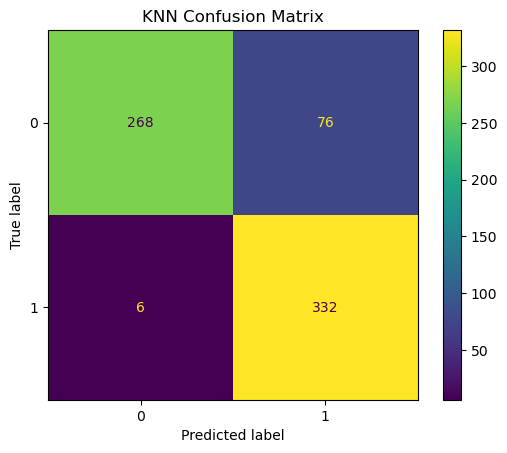

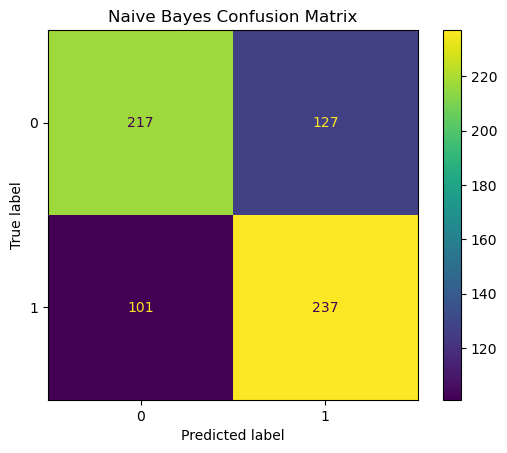

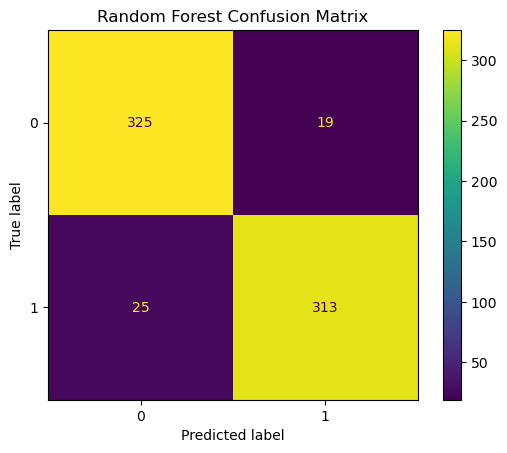

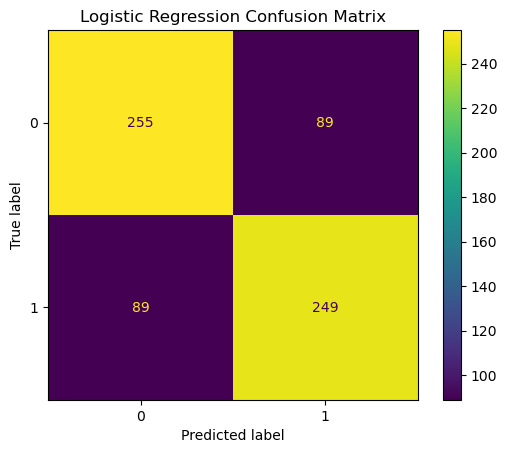

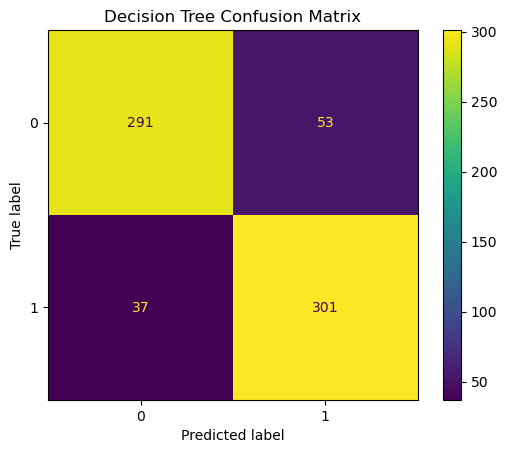

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp.plot()
plt.title("SVM Confusion Matrix")
plt.show()


# KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp.plot()
plt.title("KNN Confusion Matrix")
plt.show()


# Naive Bayes
cm_nv = confusion_matrix(y_test, y_pred_nv)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nv)
disp.plot()
plt.title("Naive Bayes Confusion Matrix")
plt.show()


# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()


# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()


# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [47]:
def evaluate_model(y_test, y_pred):
    
    acc = round(accuracy_score(y_test, y_pred), 2)
    pr  = round(precision_score(y_test, y_pred), 2)
    rc  = round(recall_score(y_test, y_pred), 2)
    f1  = round(f1_score(y_test, y_pred), 2)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    return [f'{acc*100}%', f'{pr*100}%', f'{rc*100}%', f'{f1*100}%', tp, fp, tn, fn]


models = {
    "SVM": y_pred_svm,
    "KNN": y_pred_knn,
    "Naive Bayes": y_pred_nv,
    "Random Forest": y_pred_rf,
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt
}

results = {}

for name, pred in models.items():
    results[name] = evaluate_model(y_test, pred)

combined_df = pd.DataFrame(
    results,
    index=['Accuracy','Precision','Recall','F1','TP','FP','TN','FN']
)

combined_df

,SVM,KNN,Naive Bayes,Random Forest,Logistic Regression,Decision Tree
Accuracy,88.0%,88.0%,67.0%,94.0%,74.0%,87.0%
Precision,89.0%,81.0%,65.0%,94.0%,74.0%,85.0%
Recall,87.0%,98.0%,70.0%,93.0%,74.0%,89.0%
F1,88.0%,89.0%,68.0%,93.0%,74.0%,87.0%
TP,293,332,237,313,249,301
FP,37,76,127,19,89,53
TN,307,268,217,325,255,291
FN,45,6,101,25,89,37
